<a href="https://www.kaggle.com/code/lalit7881/llm-price-performance-mar-2026?scriptVersionId=308039397" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/llm-price-performance-tracker-march-2026/llm_price_performance_tracker_2026-03-31.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/llm-price-performance-tracker-march-2026/llm_price_performance_tracker_2026-03-31.csv")

In [3]:
df.head()

,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,...,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
0,GPT-5.4 (xhigh),gpt-5-4,OpenAI,openai,a89c4b28-2d8c-456e-88ea-255fb51fd2b6,57.2,57.3,NaN,63.40,NaN,...,8.0,5618.0,500.0,2026.0,False,10.17,33.53,80.68,15.94,2026-03-31
1,Gemini 3.1 Pro Preview,gemini-3-1-pro-preview,Google,google,bbd93ebe-80da-4594-bb19-61e69d0331df,57.2,55.5,NaN,65.90,NaN,...,6.0,15809.0,NaN,2026.0,False,12.71,38.66,96.02,26.71,2026-03-31
2,GPT-5.3 Codex (xhigh),gpt-5-3-codex,OpenAI,openai,59b5b14b-5365-4ee7-824a-18a8e6309644,54.0,53.1,NaN,61.53,NaN,...,NaN,NaN,500.0,2026.0,False,11.22,34.96,NaN,19.01,2026-03-31
3,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",claude-opus-4-6-adaptive,Anthropic,anthropic,53c98840-47af-49aa-94e6-469fb17e9a1b,53.0,48.1,NaN,59.40,NaN,...,NaN,NaN,NaN,2025.0,False,5.30,24.77,NaN,6.06,2026-03-31
4,"Claude Sonnet 4.6 (Adaptive Reasoning, Max Eff...",claude-sonnet-4-6-adaptive,Anthropic,anthropic,df8d14e0-3997-4e4d-b4ad-9c047acc9c69,51.7,50.9,NaN,54.77,NaN,...,NaN,NaN,NaN,2025.0,False,8.62,28.14,NaN,12.90,2026-03-31


In [4]:
df.tail()

,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,...,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
448,Cogito v2.1 (Reasoning),cogito-v2-1-reasoning,Deep Cogito,deepcogito,ea5d2c10-1051-437d-95c2-18d5e4d14ff3,NaN,24.8,72.7,56.50,0.849,...,NaN,NaN,NaN,NaN,True,NaN,69.67,NaN,74.03,2026-03-31
449,Mi:dm K 2.5 Pro Preview,midm-250-pro-rsnsft,Korea Telecom,korea-telecom,e0099b99-d368-4562-b0de-4016ea58af54,NaN,11.9,78.7,49.92,0.813,...,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,2026-03-31
450,GPT-4o Realtime (Dec '24),gpt-4o-realtime-dec-2024,OpenAI,openai,e2e9ddc3-8c2d-4bf5-a60a-83a1afe61034,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,200.0,2024.0,False,NaN,NaN,NaN,NaN,2026-03-31
451,GPT-3.5 Turbo (0613),gpt-3-5-turbo-0613,OpenAI,openai,8b1a70d1-e05f-426b-9122-023d4629ab47,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,2026-03-31
452,GPT-4o mini Realtime (Dec '24),gpt-4o-mini-realtime-dec-2024,OpenAI,openai,4343afb1-c928-44c9-92e2-68fa1195b6f5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,8.0,2025.0,False,NaN,NaN,NaN,NaN,2026-03-31


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   model_name                453 non-null    object 
 1   model_slug                453 non-null    object 
 2   provider                  453 non-null    object 
 3   provider_slug             453 non-null    object 
 4   aa_id                     453 non-null    object 
 5   aa_intelligence_index     446 non-null    float64
 6   aa_coding_index           356 non-null    float64
 7   aa_math_index             268 non-null    float64
 8   composite_benchmark       433 non-null    float64
 9   mmlu_pro                  344 non-null    float64
 10  gpqa_diamond              424 non-null    float64
 11  humanitys_last_exam       420 non-null    float64
 12  livecodebench             342 non-null    float64
 13  scicode                   418 non-null    float64
 14  math_500  

In [6]:
df.describe()

,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,gpqa_diamond,humanitys_last_exam,livecodebench,scicode,math_500,...,time_to_first_answer_s,chatbot_arena_elo,arena_elo_ci95,arena_votes,parameter_count,release_year,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar
count,446.000000,356.000000,268.000000,433.000000,344.000000,424.000000,420.000000,342.000000,418.000000,201.000000,...,279.000000,46.000000,46.000000,46.000000,286.000000,292.000000,297.000000,295.000000,46.00000,263.000000
mean,21.241256,19.507022,50.358209,43.885358,0.695875,0.597344,0.089479,0.444488,0.282156,0.763821,...,13.234559,1441.586957,5.500000,28526.456522,168.665734,2025.304795,56.694377,132.377085,45.59087,652.151863
std,11.969957,12.756695,30.683282,15.960437,0.167493,0.193779,0.074591,0.250330,0.126316,0.218255,...,21.447354,23.408997,1.929306,23704.998901,234.257631,0.853280,80.906908,140.634859,22.16947,2010.831957
min,4.700000,0.000000,0.000000,4.100000,0.055000,0.098000,0.012000,0.002000,0.000000,0.059000,...,0.199000,1412.000000,3.000000,2860.000000,0.600000,2023.000000,0.100000,9.730000,13.51000,0.790000
25%,12.000000,10.000000,23.350000,33.670000,0.633750,0.433750,0.044000,0.235750,0.193250,0.677000,...,0.582000,1422.000000,4.000000,11526.250000,9.250000,2025.000000,10.760000,42.620000,26.02250,38.315000
50%,17.950000,16.650000,52.800000,45.720000,0.752000,0.623000,0.055500,0.423000,0.295500,0.835000,...,1.551000,1436.500000,5.000000,20967.000000,49.000000,2026.000000,29.700000,82.940000,42.54500,119.170000
75%,28.475000,28.750000,79.475000,53.860000,0.814250,0.764000,0.103000,0.667500,0.377000,0.939000,...,18.249000,1454.000000,6.000000,38311.500000,235.000000,2026.000000,70.340000,174.565000,63.39500,473.960000
max,57.200000,57.300000,99.000000,95.400000,0.898000,0.941000,0.447000,0.917000,0.589000,0.994000,...,159.489000,1500.000000,11.000000,103891.000000,1200.000000,2026.000000,525.000000,1135.680000,96.02000,20735.850000


In [7]:
df.columns

Index(['model_name', 'model_slug', 'provider', 'provider_slug', 'aa_id',
       'aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
       'composite_benchmark', 'mmlu_pro', 'gpqa_diamond',
       'humanitys_last_exam', 'livecodebench', 'scicode', 'math_500',
       'aime_2025', 'input_cost_usd_per_1m', 'output_cost_usd_per_1m',
       'blended_cost_usd_per_1m', 'pricing_tier', 'output_tokens_per_second',
       'time_to_first_token_s', 'time_to_first_answer_s', 'chatbot_arena_elo',
       'arena_elo_ci95', 'arena_votes', 'parameter_count', 'release_year',
       'is_open_source', 'intelligence_per_dollar', 'price_performance_ratio',
       'elo_benchmark_blend', 'speed_per_dollar', 'scrape_date'],
      dtype='object')

In [8]:
df.isnull().sum()

model_name                    0
model_slug                    0
provider                      0
provider_slug                 0
aa_id                         0
aa_intelligence_index         7
aa_coding_index              97
aa_math_index               185
composite_benchmark          20
mmlu_pro                    109
gpqa_diamond                 29
humanitys_last_exam          33
livecodebench               111
scicode                      35
math_500                    252
aime_2025                   259
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
pricing_tier                  0
output_tokens_per_second    174
time_to_first_token_s       174
time_to_first_answer_s      174
chatbot_arena_elo           407
arena_elo_ci95              407
arena_votes                 407
parameter_count             167
release_year                161
is_open_source                0
intelligence_per_dollar     156
price_performance_ratio     158
elo_benc

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

model_name                   object
model_slug                   object
provider                     object
provider_slug                object
aa_id                        object
aa_intelligence_index       float64
aa_coding_index             float64
aa_math_index               float64
composite_benchmark         float64
mmlu_pro                    float64
gpqa_diamond                float64
humanitys_last_exam         float64
livecodebench               float64
scicode                     float64
math_500                    float64
aime_2025                   float64
input_cost_usd_per_1m       float64
output_cost_usd_per_1m      float64
blended_cost_usd_per_1m     float64
pricing_tier                 object
output_tokens_per_second    float64
time_to_first_token_s       float64
time_to_first_answer_s      float64
chatbot_arena_elo           float64
arena_elo_ci95              float64
arena_votes                 float64
parameter_count             float64
release_year                

In [11]:
df.shape

(453, 34)

In [12]:
df.nunique()

model_name                  453
model_slug                  453
provider                     47
provider_slug                47
aa_id                       453
aa_intelligence_index       266
aa_coding_index             244
aa_math_index               173
composite_benchmark         413
mmlu_pro                    234
gpqa_diamond                323
humanitys_last_exam         151
livecodebench               281
scicode                     249
math_500                    168
aime_2025                   127
input_cost_usd_per_1m        67
output_cost_usd_per_1m       87
blended_cost_usd_per_1m     121
pricing_tier                  6
output_tokens_per_second    278
time_to_first_token_s       267
time_to_first_answer_s      273
chatbot_arena_elo            30
arena_elo_ci95                8
arena_votes                  41
parameter_count              63
release_year                  4
is_open_source                2
intelligence_per_dollar     293
price_performance_ratio     291
elo_benc

## EDA

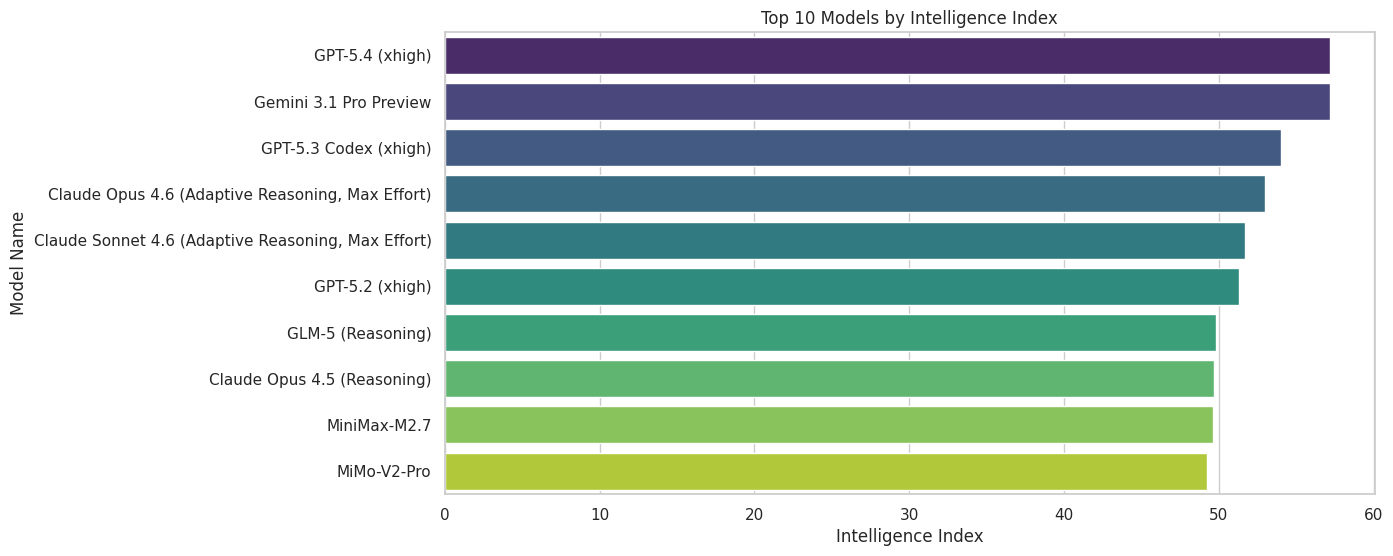

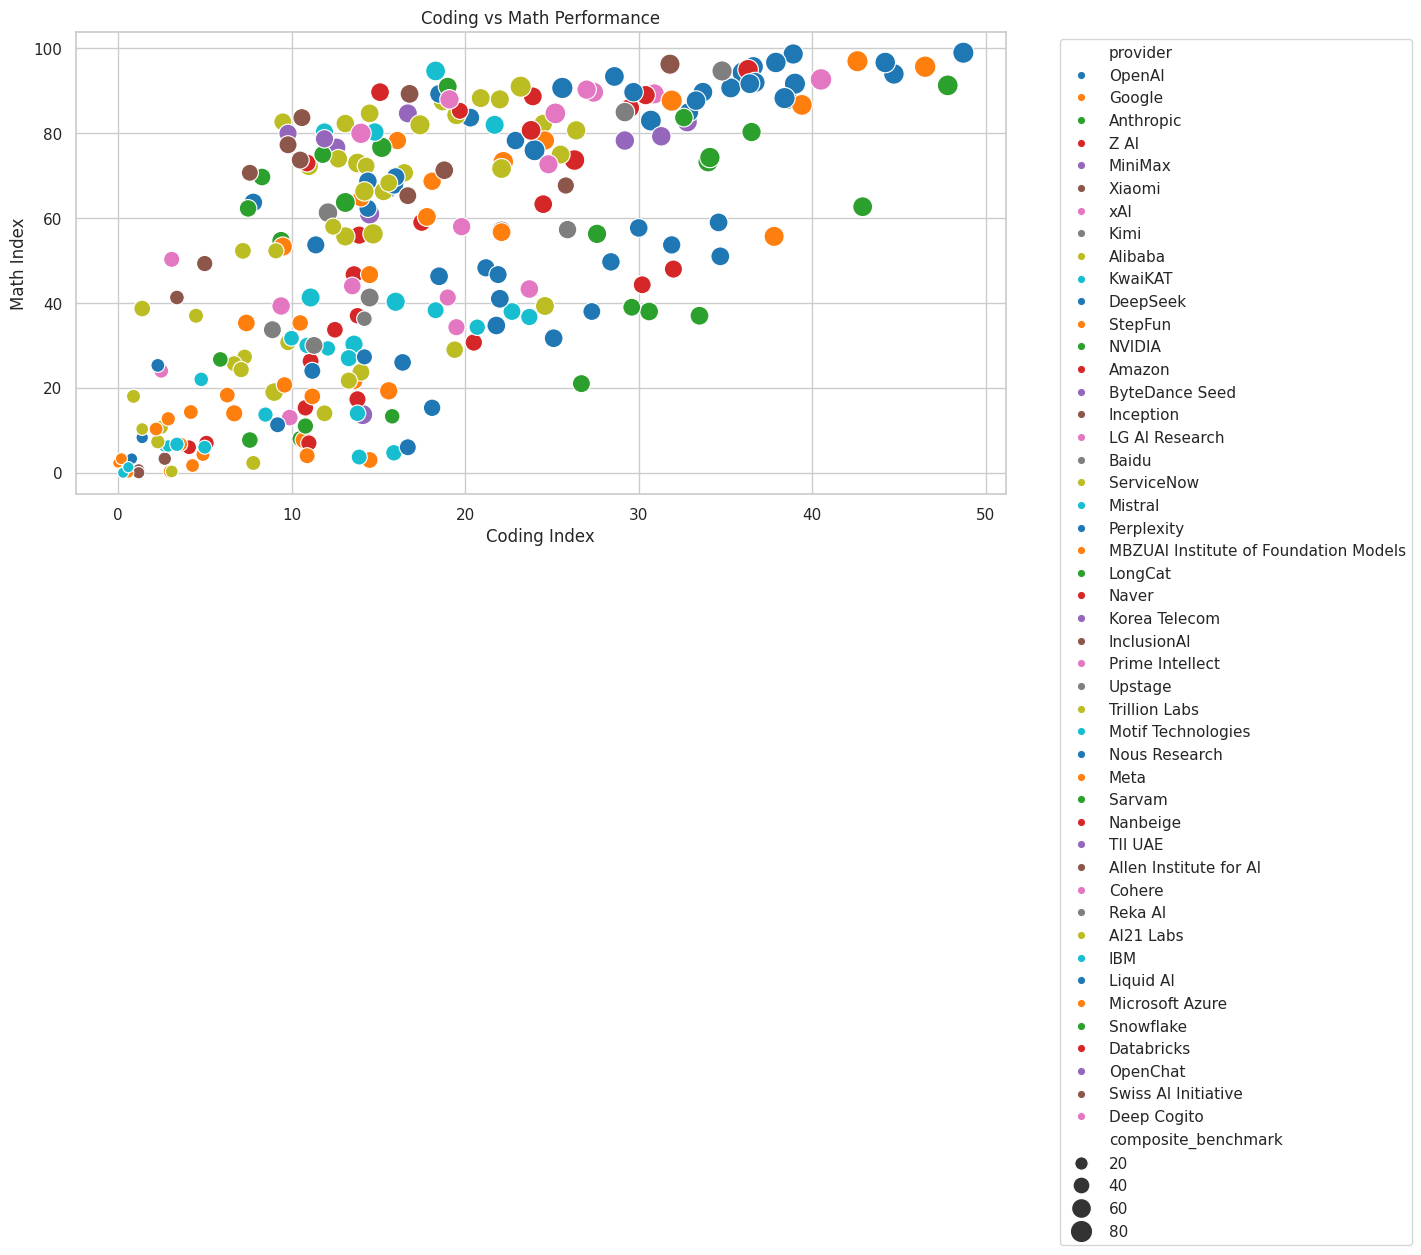

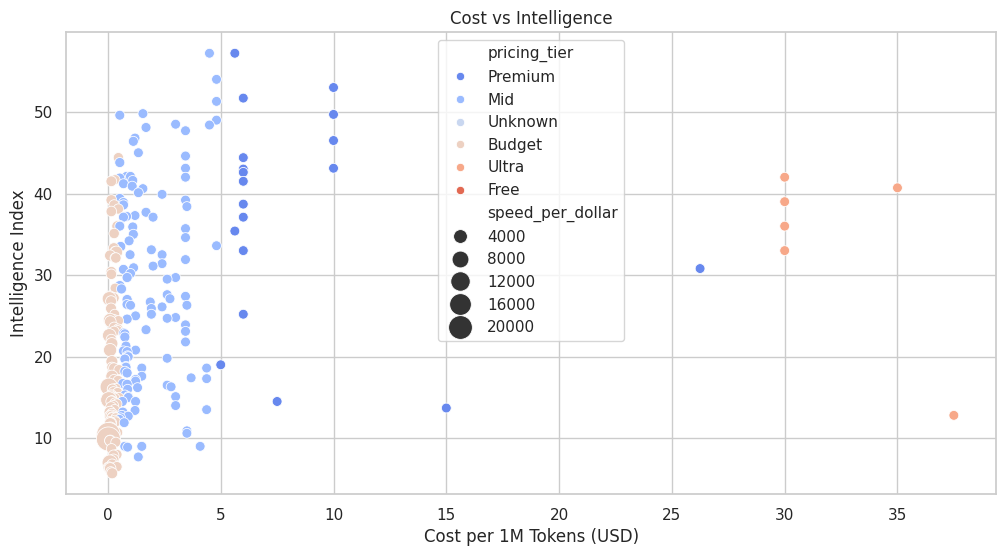

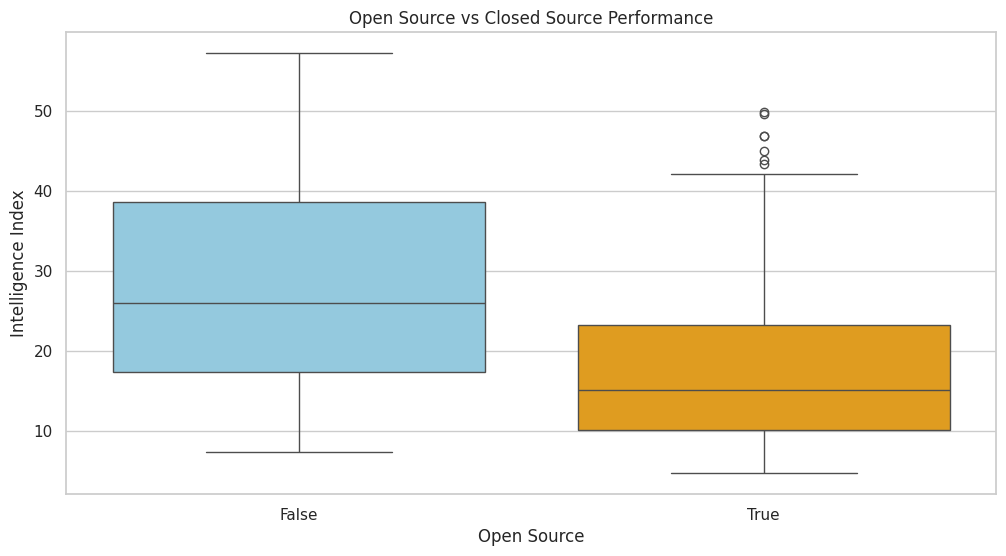

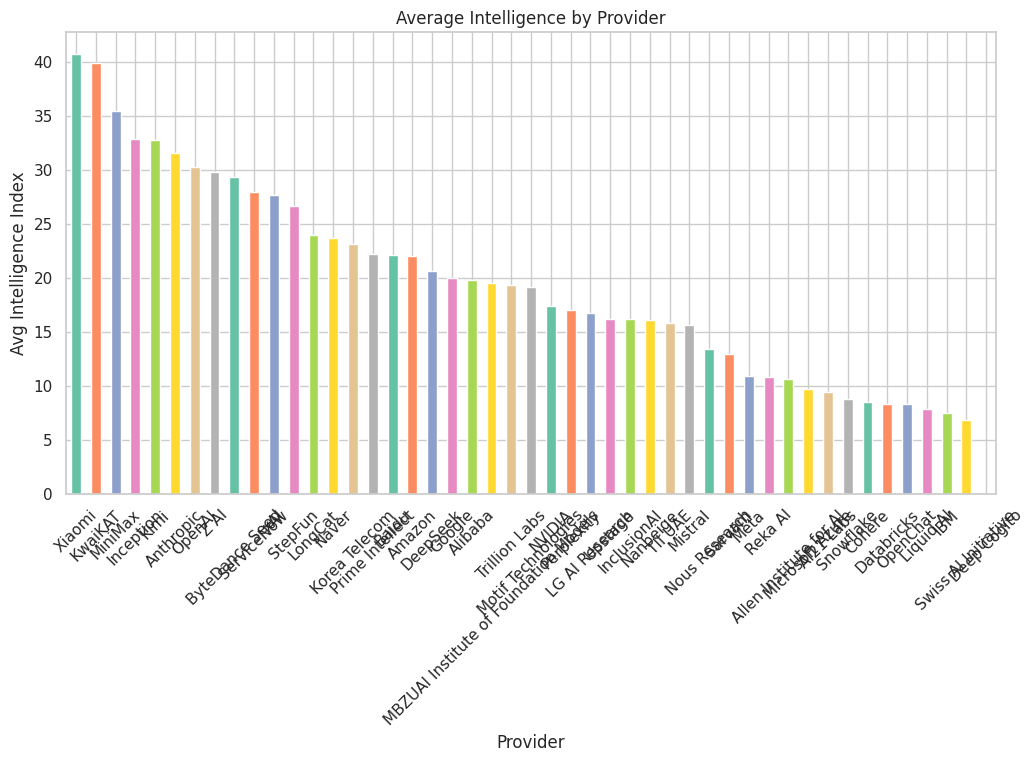

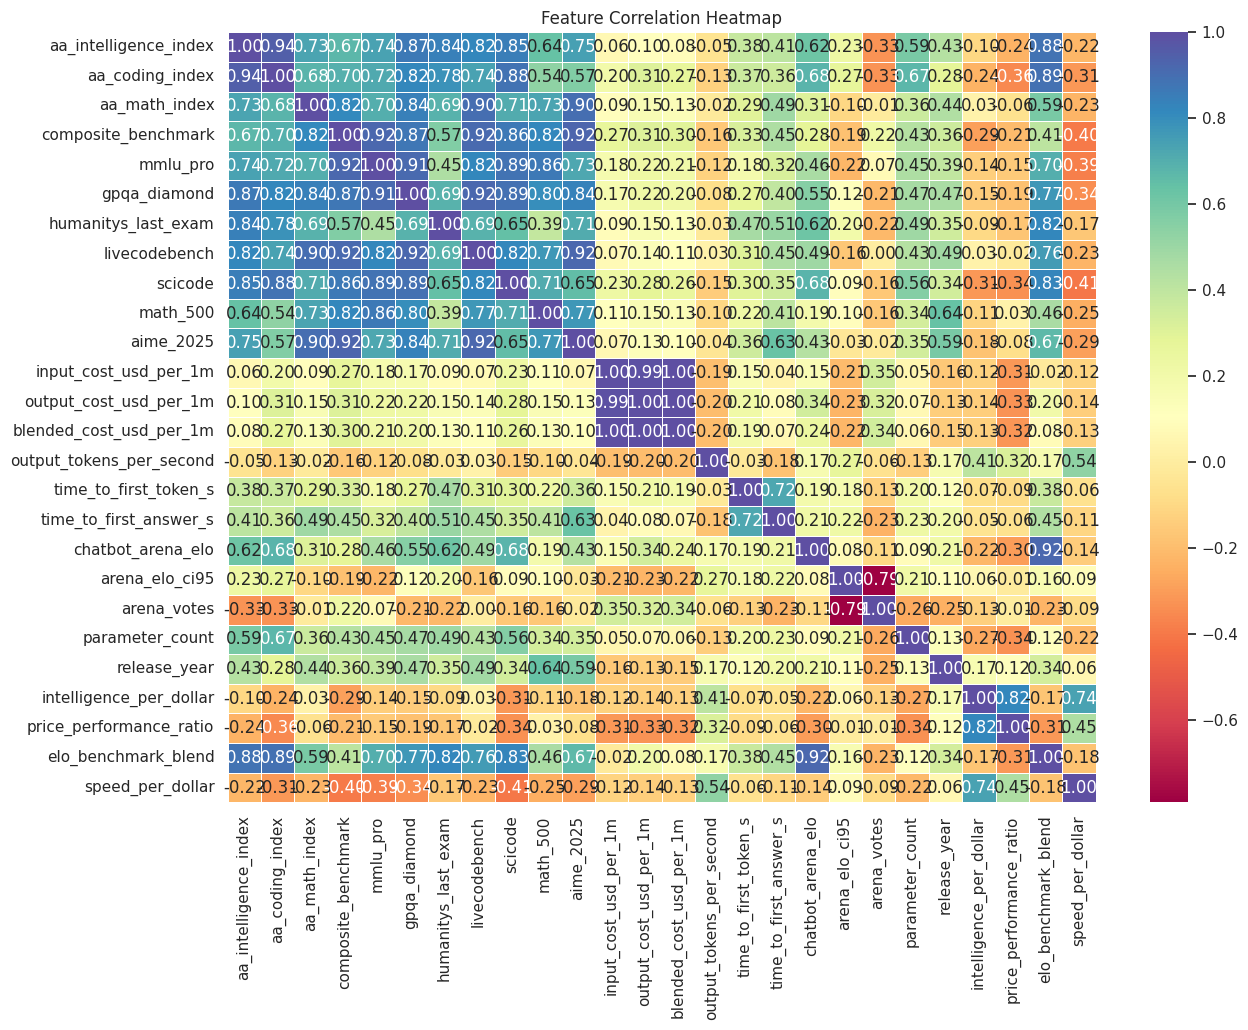

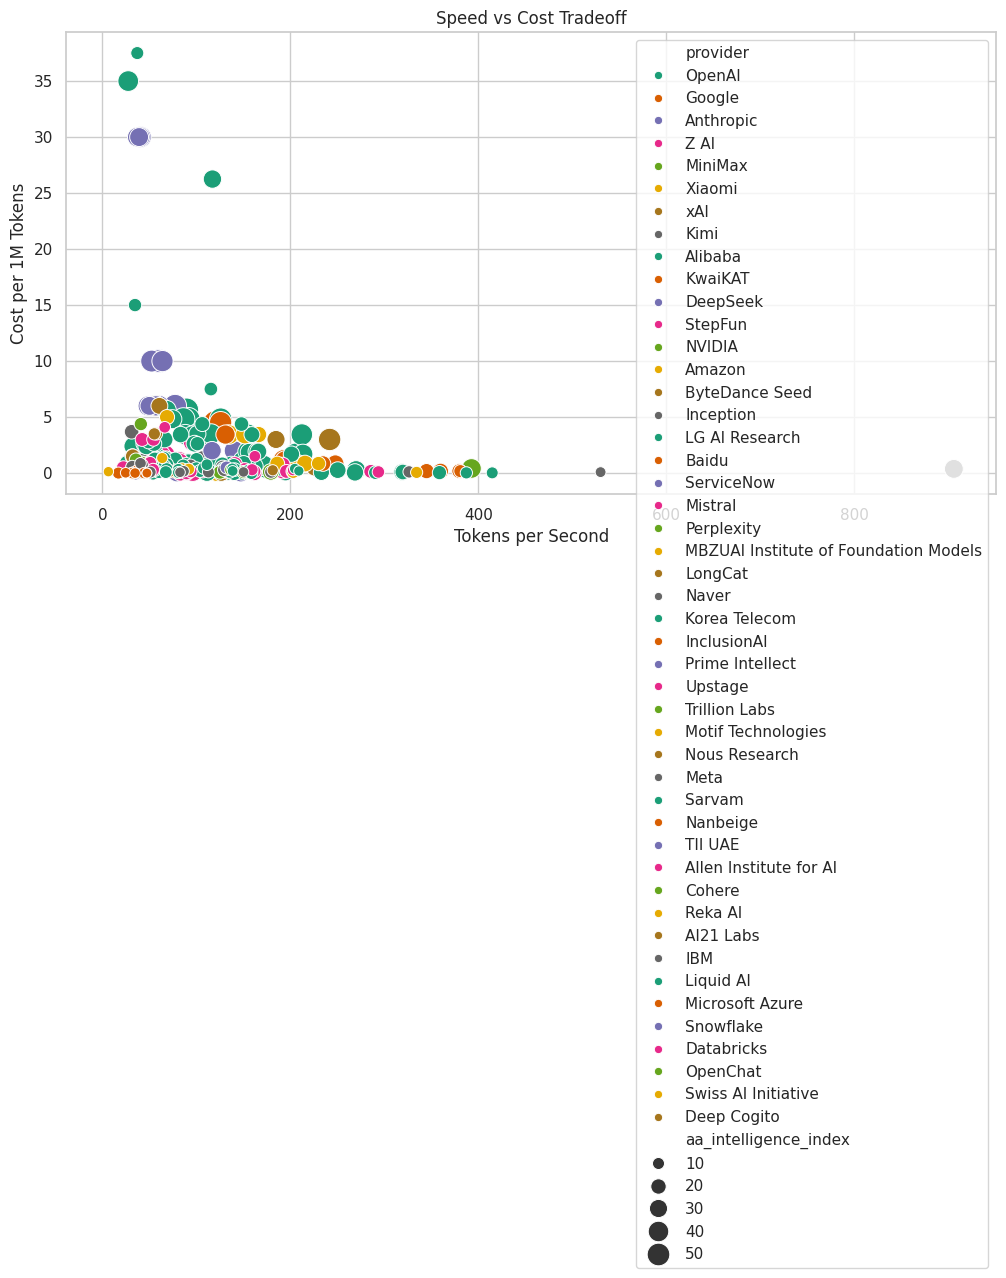

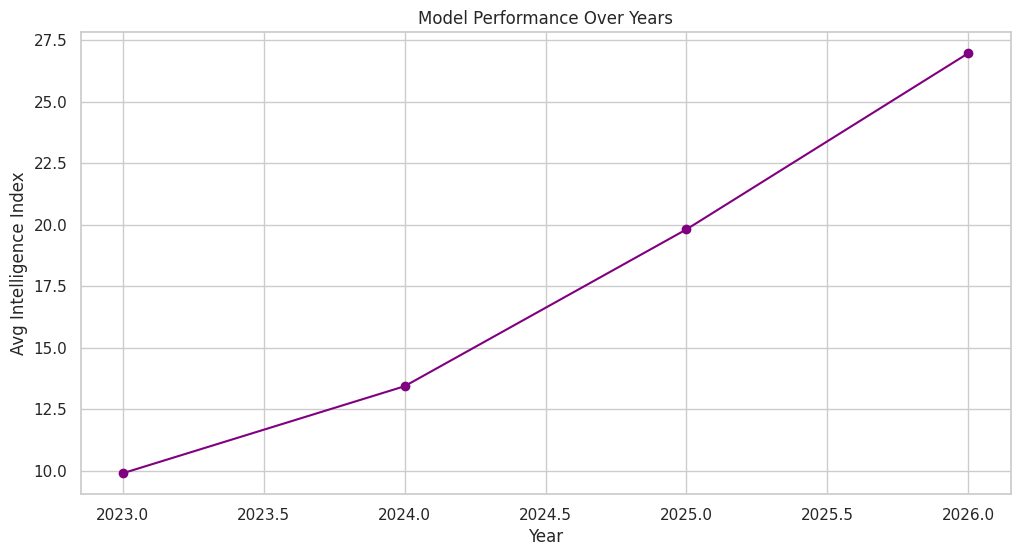

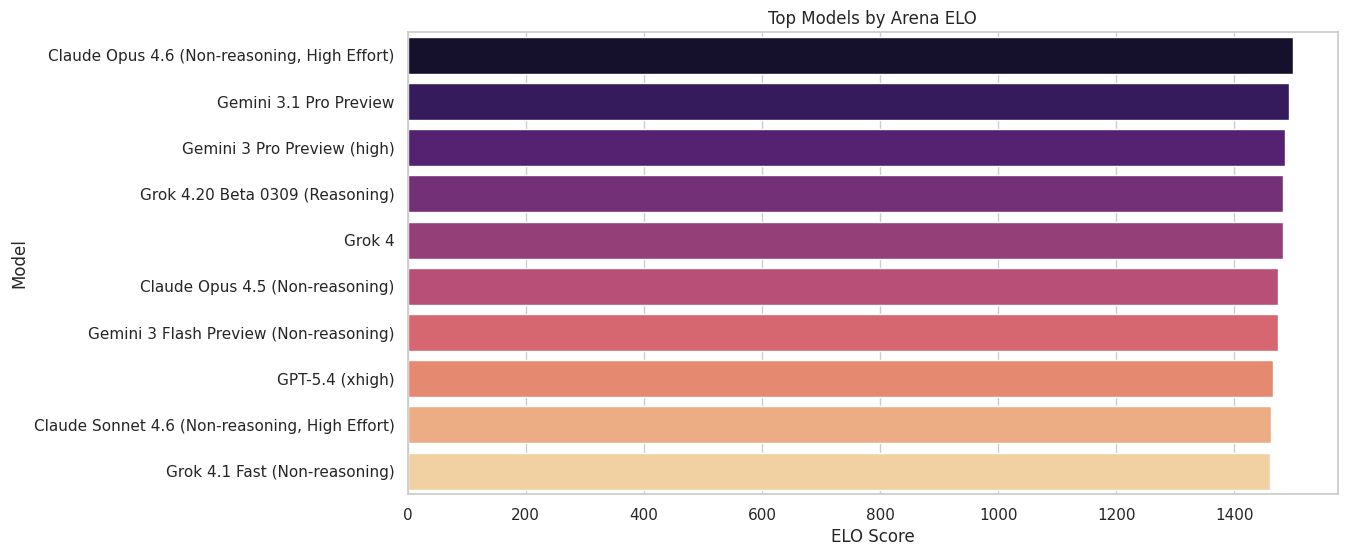

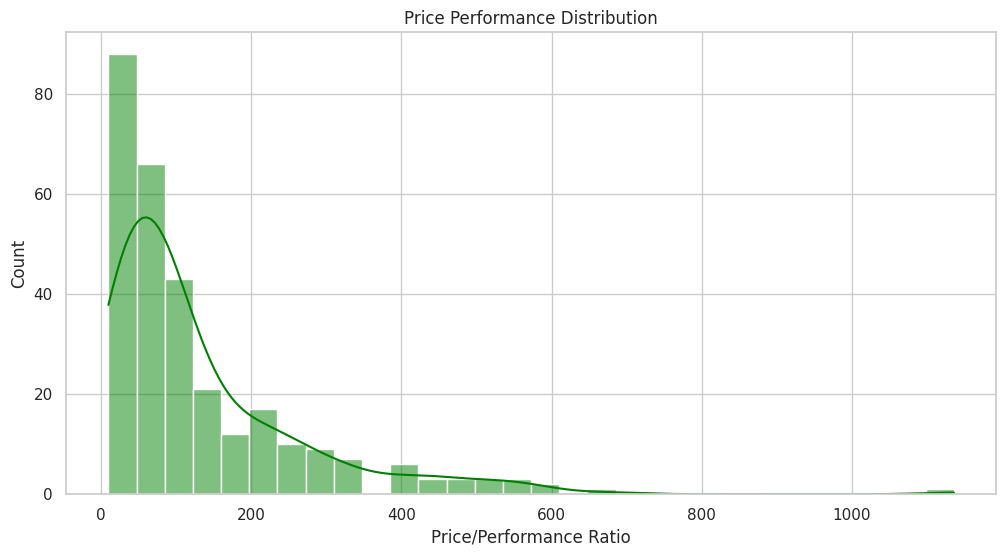

In [13]:
# -----------------------------
# Basic Setup
# -----------------------------
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# -----------------------------
# 1. Top Models by Intelligence Index
# -----------------------------
top_intel = df.sort_values(by='aa_intelligence_index', ascending=False).head(10)

plt.figure()
sns.barplot(
    data=top_intel,
    x='aa_intelligence_index',
    y='model_name',
    palette='viridis'
)
plt.title("Top 10 Models by Intelligence Index")
plt.xlabel("Intelligence Index")
plt.ylabel("Model Name")
plt.show()

# -----------------------------
# 2. Coding vs Math Performance
# -----------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x='aa_coding_index',
    y='aa_math_index',
    hue='provider',
    palette='tab10',
    size='composite_benchmark',
    sizes=(50, 300)
)
plt.title("Coding vs Math Performance")
plt.xlabel("Coding Index")
plt.ylabel("Math Index")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# -----------------------------
# 3. Cost vs Performance
# -----------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x='blended_cost_usd_per_1m',
    y='aa_intelligence_index',
    hue='pricing_tier',
    palette='coolwarm',
    size='speed_per_dollar',
    sizes=(50, 300)
)
plt.title("Cost vs Intelligence")
plt.xlabel("Cost per 1M Tokens (USD)")
plt.ylabel("Intelligence Index")
plt.show()

# -----------------------------
# 4. Open Source vs Closed Source
# -----------------------------
plt.figure()
sns.boxplot(
    data=df,
    x='is_open_source',
    y='aa_intelligence_index',
    palette=['skyblue', 'orange']
)
plt.title("Open Source vs Closed Source Performance")
plt.xlabel("Open Source")
plt.ylabel("Intelligence Index")
plt.show()

# -----------------------------
# 5. Provider Comparison
# -----------------------------
provider_perf = df.groupby('provider')['aa_intelligence_index'].mean().sort_values(ascending=False)

plt.figure()
provider_perf.plot(
    kind='bar',
    color=sns.color_palette('Set2')
)
plt.title("Average Intelligence by Provider")
plt.xlabel("Provider")
plt.ylabel("Avg Intelligence Index")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 6. Correlation Heatmap
# -----------------------------
num_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(14,10))
sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='Spectral',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# -----------------------------
# 7. Speed vs Cost
# -----------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x='output_tokens_per_second',
    y='blended_cost_usd_per_1m',
    hue='provider',
    palette='Dark2',
    size='aa_intelligence_index',
    sizes=(50, 300)
)
plt.title("Speed vs Cost Tradeoff")
plt.xlabel("Tokens per Second")
plt.ylabel("Cost per 1M Tokens")
plt.show()

# -----------------------------
# 8. Release Year Trend
# -----------------------------
year_perf = df.groupby('release_year')['aa_intelligence_index'].mean()

plt.figure()
year_perf.plot(
    marker='o',
    linestyle='-',
    color='purple'
)
plt.title("Model Performance Over Years")
plt.xlabel("Year")
plt.ylabel("Avg Intelligence Index")
plt.show()

# -----------------------------
# 9. Top Models by Arena ELO
# -----------------------------
top_elo = df.sort_values(by='chatbot_arena_elo', ascending=False).head(10)

plt.figure()
sns.barplot(
    data=top_elo,
    x='chatbot_arena_elo',
    y='model_name',
    palette='magma'
)
plt.title("Top Models by Arena ELO")
plt.xlabel("ELO Score")
plt.ylabel("Model")
plt.show()

# -----------------------------
# 10. Price vs Performance Ratio
# -----------------------------
plt.figure()
sns.histplot(
    df['price_performance_ratio'],
    bins=30,
    kde=True,
    color='green'
)
plt.title("Price Performance Distribution")
plt.xlabel("Price/Performance Ratio")
plt.show()

Using target: aa_intelligence_index

Logistic Regression
Accuracy: 0.8571
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        46
           1       0.92      0.78      0.84        45

    accuracy                           0.86        91
   macro avg       0.87      0.86      0.86        91
weighted avg       0.87      0.86      0.86        91


Random Forest
Accuracy: 0.9011
              precision    recall  f1-score   support

           0       0.86      0.96      0.91        46
           1       0.95      0.84      0.89        45

    accuracy                           0.90        91
   macro avg       0.91      0.90      0.90        91
weighted avg       0.91      0.90      0.90        91


Gradient Boosting
Accuracy: 0.9121
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        46
           1       0.95      0.87      0.91        45

    accuracy                           0

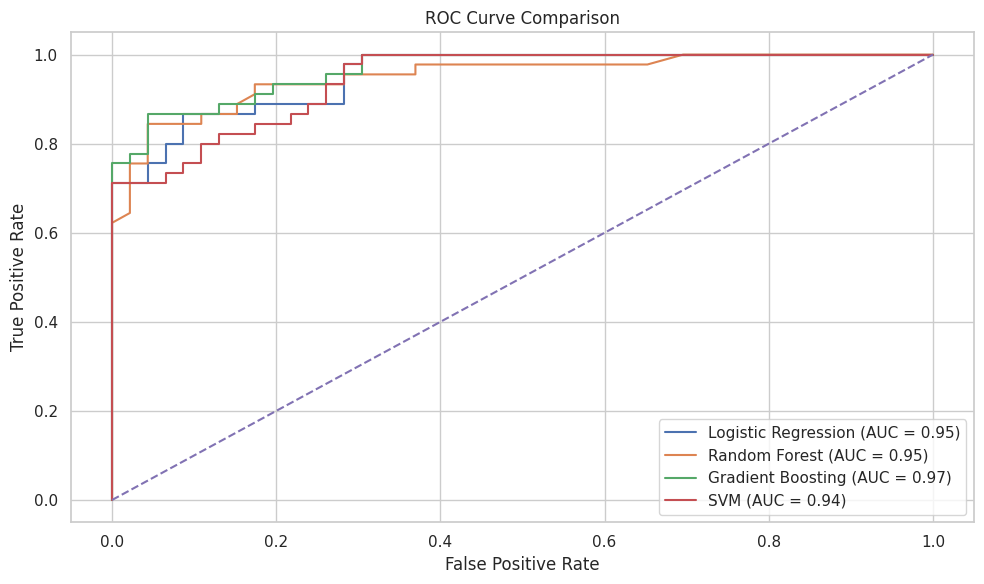

In [14]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# -----------------------------
# STEP 1: CLEAN COLUMN NAMES
# -----------------------------
df = df.copy()
df.columns = df.columns.str.strip().str.lower()

# -----------------------------
# STEP 2: TARGET SELECTION
# -----------------------------
possible_targets = [
    'aa_intelligence_index',
    'chatbot_arena_elo',
    'composite_benchmark',
    'elo_benchmark_blend'
]

target_col = next((col for col in possible_targets if col in df.columns), None)

if target_col is None:
    raise ValueError("No valid target column found!")

print("Using target:", target_col)

# -----------------------------
# STEP 3: CREATE TARGET
# -----------------------------
threshold = df[target_col].median()
df['target'] = (df[target_col] >= threshold).astype(int)

# -----------------------------
# STEP 4: DROP LEAKAGE
# -----------------------------
df = df.drop(columns=[
    target_col, 'model_name', 'model_slug', 'provider_slug', 'aa_id'
], errors='ignore')

# -----------------------------
# STEP 5: SPLIT FEATURES
# -----------------------------
X = df.drop('target', axis=1)
y = df['target']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# -----------------------------
# ✅ STEP 6: FIX NaN (CRITICAL)
# -----------------------------
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # FIX
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # FIX
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

# -----------------------------
# STEP 7: TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# STEP 8: MODELS
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

# -----------------------------
# STEP 9: TRAIN + EVALUATE
# -----------------------------
plt.figure(figsize=(10, 6))

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    
    # Probabilities
    if hasattr(pipe.named_steps['model'], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipe.decision_function(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print("\n" + "="*50)
    print(name)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# -----------------------------
# STEP 10: ROC CURVE
# -----------------------------
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!!!!!